In [1]:
# adapted from https://github.com/uk-cliplab/representation-itl/blob/main/src/repitl/matrix_itl.py
import torch

def generalizedInformationPotential(K, alpha, allow_frobenius_speedup=True):
    """Computes the generalized information 
    potential of order alpha
          GIP_alpha(K) = trace(K_^alpha), 
    where K^alpha is a matrix raised to the alpha power. 
    K_ is normalized as K_ = K / trace(K), such that 
          trace(K_) = 1.
   
    Args:
      K: (N x N) Gram matrix.
      alpha: order of the entropy.
    
    Returns:
      GIP: generalized information potential of alpha order. 
    """
    if allow_frobenius_speedup and alpha == 2:
        return frobeniusGIP(K)
    
    ek, _ = torch.linalg.eigh(K)  
    mk = torch.gt(ek, 0.0)
    mek = ek[mk]
    mek = mek / torch.sum(mek)
    GIP = torch.sum(torch.exp(alpha * torch.log(mek)))
    return GIP


def frobeniusGIP(K):
    """
    calculates entropy using the frobenius norm trick
    equivalent result to calling generalizedInformationPotential(K, alpha=2), but this is much faster

    todo: due to symmetricity of K, can be twice as fast be only considering the lower triangle
    
    Args:
        K: (N x N) Gram matrix
    """
    GIP = torch.sum(torch.pow(K, 2))
    
    # normalize so that the sum of eigenvalues is 1
    GIP /= K.shape[0]**2
    
    return GIP

def vonNeumannEntropy(K, lowRank = False, rank = None):
    n = K.shape[0]
    ek, _ = torch.linalg.eigh(K)
    if lowRank:
        ek_lr = torch.zeros_like(ek)
        ek_lr[-rank:] = ek[-rank:]
        remainder = ek.sum() - ek_lr.sum()
        ek_lr[:(n-rank)] = remainder/(n-rank)
        mk = torch.gt(ek_lr, 0.0)
        mek = ek_lr[mk]
    else:
        mk = torch.gt(ek, 0.0)
        mek = ek[mk]

    mek = mek/mek.sum()   
    H = -1*torch.sum(mek*torch.log(mek))
    return H

def matrixAlphaEntropy(K, alpha):
    """Computes the matrix based alpha-entropy
    based on the spectrum of K
        H_alpha(A) = (1/(1-alpha))log(trace(A^alpha)), 
    where A^alpha is the matrix power of alpha (A is normalized).
    
    
    Args:
      A: (N x N) Gram matrix.
      alpha: order of the entropy.
    
    Returns:
      H: alpha entropy 
    """
    # handle limit case
    if alpha==1:
        return vonNeumannEntropy(K)

    # compute generalized information Potential
    GIP = generalizedInformationPotential(K, alpha).real
    H = (1.0 / (1.0 - alpha)) * torch.log(GIP)
    return H

In [2]:
import torch
import math

def entropy_normalization(entropy, normalization, N, D):
    """
    Normalize the entropy based on the specified normalization method.

    Args:
        entropy (float): The entropy value to be normalized.
        normalization (str): The normalization method to use.
        N (int): The number of samples.
        D (int): The dimensionality of the data.

    Returns:
        float: The normalized entropy value.
    """
    assert normalization in ['maxEntropy', 'logN', 'logD', 'logNlogD', 'raw', 'length']

    if normalization == 'maxEntropy':
        entropy /= min(math.log(N), math.log(D))
    elif normalization == 'logN':
        entropy /= math.log(N)
    elif normalization == 'logD':
        entropy /= math.log(D)
    elif normalization == 'logNlogD':
        entropy /= (math.log(N) * math.log(D))
    elif normalization == 'raw':
        pass
    elif normalization == 'length':
        entropy = N

    return entropy



def compute_entropy(hidden_states, alpha=1, normalizations=['maxEntropy']):
    L, N, D = hidden_states.shape

    if N > D:
        cov = torch.matmul(hidden_states.transpose(1, 2), hidden_states) # L x N x N
    else:
        cov = torch.matmul(hidden_states, hidden_states.transpose(1, 2)) # L x D x D

    cov = torch.clamp(cov, min=0)
    entropies = [matrixAlphaEntropy(LAYER_COV.double(), alpha=alpha).item() for LAYER_COV in cov]

    return {norm: [entropy_normalization(x, norm, N, D) for x in entropies] for norm in normalizations}

# Dataloader Code

In [3]:
import os
import math
import warnings
from typing import List

import numpy as np
import torch
import tqdm
import umap
from datasets import Dataset, load_dataset, load_from_disk
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

os.environ["TOKENIZERS_PARALLELISM"] = "false"

datasets = ['wikitext', 'ai-medical-dataset', 'custom']

def get_dataloader(
        tokenizer, 
        dataset_name, 
        split='train', 
        context_length_ratio=1, 
        min_length=5,
        max_length=None, 
        num_samples=10000, 
        filter_text_columns=True, 
        augment=False,
        return_dataset=False,
        max_sample_length=2048,
        num_workers=8,
        batch_size=1,
        custom_dataset=[]
    ):
    
    def find_data_key_in_examples(examples):
        if "text" in examples:
            return "text"
        elif "sentences" in examples:
            return "sentences"
        elif "query" in examples:
            return "query"
        elif "sentence1" in examples and "sentence2" in examples:
            return "sentence1"
        else:
            raise ValueError("No text or sentences column found in examples, valid columns: ", examples.keys())

    def general_tokenize_function(examples):
        data_key = find_data_key_in_examples(examples)
        sentences = examples[data_key]
        if isinstance(sentences[0], list):
            sentences = [item for sublist in sentences for item in sublist]

        if not augment:
            texts = sentences
        else:
            texts = text_augmentation(sentences) 

        return tokenizer(texts, truncation=True, max_length=max_sample_length)
    
    def medical_tokenize_function(examples):
        medical_prompt = """You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            {}


            ### Response:
            {}"""
        
        instructions = examples["question"]
        outputs      = examples["context"]
        texts = []
        for instruction, output in zip(instructions,  outputs):
            # Must add EOS_TOKEN, otherwise your generation will go on forever!
            text = medical_prompt.format(instruction,  output)
            texts.append(text)

        return tokenizer(texts, truncation=True, max_length=max_sample_length)
    
    def adjust_context_length(examples):
        if context_length_ratio == 1:
            return examples
        else:
            input_length = len(examples['input_ids'])
            context_length = max(2, int(input_length * context_length_ratio))
            examples['attention_mask'] = examples['attention_mask'][:context_length]
            examples['input_ids'] = examples['input_ids'][:context_length]

            return examples

    def is_not_wikipedia_heading(example):
        return not (example["text"].strip().startswith("=") and example["text"].strip().endswith("="))

    assert dataset_name in datasets or 'mteb' in dataset_name
    assert context_length_ratio <= 1

    if dataset_name == 'wikitext':
        dataset = load_dataset("wikitext", 'wikitext-103-v1')[split]
    
        # filter out unneeded samples
        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))
        dataset = dataset.filter(is_not_wikipedia_heading) # filter out headings
        
        # filter out samples by lower bound and upper bound on length
        dataset = dataset.filter(lambda x: len(x['text']) >= 2*min_length) # filter out the frequent blank/small examples in the dataset
        if max_length is not None:
            dataset = dataset.filter(lambda x: len(x['text']) <= 2*max_length)

        # tokenize the dataset
        try:
            tokenized_dataset = dataset.map(general_tokenize_function, batched=True).shuffle(seed=42)
            tokenized_dataset.set_format("torch")
        except Exception as e:
            for idx, d in enumerate(dataset):
                print(idx, d)
            raise e
        
        if filter_text_columns:
            tokenized_dataset = tokenized_dataset.remove_columns(["text"])

    elif dataset_name == 'ai-medical-dataset':
        dataset = load_dataset("ruslanmv/ai-medical-dataset")[split]
    
        # filter out unneeded samples
        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))

        # tokenize the dataset
        tokenized_dataset = dataset.map(medical_tokenize_function, batched=True).shuffle(seed=42)
        tokenized_dataset.set_format("torch")

        if filter_text_columns:
            tokenized_dataset = tokenized_dataset.remove_columns(["question"])
            tokenized_dataset = tokenized_dataset.remove_columns(["context"])

        # filter out samples by lower bound and upper bound on length
        tokenized_dataset = tokenized_dataset.filter(lambda x: len(x['input_ids']) >= min_length) # filter out the frequent blank/small examples in the dataset
        if max_length is not None:
            tokenized_dataset = tokenized_dataset.filter(lambda x: len(x['input_ids']) <= max_length)

    elif dataset_name == 'custom':
        my_data = {"text": custom_dataset}
        dataset = Dataset.from_dict(my_data)
        
        # tokenize the dataset
        try:
            tokenized_dataset = dataset.map(general_tokenize_function, batched=True).shuffle(seed=42)
            tokenized_dataset = tokenized_dataset.remove_columns(["text"])
            tokenized_dataset.set_format("torch")
        except Exception as e:
            for idx, d in enumerate(dataset):
                print(idx, d)
            raise e


    elif 'mteb' in dataset_name:
        try:
            dataset = load_dataset(dataset_name)[split]
        except KeyError as e:
            print(f"Failed to load dataset {dataset_name} with split {split} with error {e}")
            raise e

        data_key = find_data_key_in_examples(dataset[0])
        if isinstance(dataset[0][data_key], list):
            # data is splits, choose the first split
            sentences = [item for item in dataset[0][data_key]]
            dataset = Dataset.from_dict({"text": sentences})

        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))

        tokenized_dataset = dataset.map(general_tokenize_function, batched=True).shuffle(seed=42)
        tokenized_dataset.set_format("torch")

        if filter_text_columns:
            for column in tokenized_dataset.column_names:
                if column not in ['input_ids', 'attention_mask']:
                    tokenized_dataset = tokenized_dataset.remove_columns([column])


    # if context_length_ratio < 1, reduce all sentences to that ratio of length
    tokenized_dataset = tokenized_dataset.map(adjust_context_length, batched=False)

    if return_dataset:
        return tokenized_dataset
    
    # form dataloader
    dataloader = DataLoader(tokenized_dataset, 
                            shuffle=False, 
                            num_workers=num_workers, 
                            batch_size=batch_size)
    return dataloader

# Make model and dataloader

In [27]:
#LOAD QWEN Sequences
import json

path = 'data/Qwen2.5-Math-1.5B-Instruct/math_eval/gsm8k/test_qwen25-math-cot_-1_seed0_t0.0_s0_e-1.jsonl'
#path = 'data/Qwen2.5-1.5B-Instruct/math_eval/gsm8k/test_qwen25-math-cot_-1_seed0_t0.0_s0_e-1.jsonl'

with open(path, 'r') as file:
    data = [json.loads(line) for line in file]
    
qwen2_mat_cot = ("<|im_start|>system\nPlease reason step by step, and put your final answer within \\boxed{{}}.<|im_end|>\n"
        "<|im_start|>user\n{input}<|im_end|>\n"
        "<|im_start|>assistant\n"
        "{output}")

full_traces = []

n = len(data)
print(n)

for idx in range(n):
        full_cot_trace = qwen2_mat_cot.replace('{input}', data[idx]['question']).replace('{output}', data[idx]['code'][0])
        full_traces.append(full_cot_trace)

1319


In [28]:
from transformers import AutoTokenizer, AutoModel
model_path = 'Qwen/Qwen2.5-Math-1.5B-Instruct'
#model_path = 'Qwen/Qwen2.5-1.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path, output_hidden_states=True, device_map="auto", torch_dtype=torch.float16)

dataloader = get_dataloader(tokenizer, "custom", split="train", num_samples=1000, custom_dataset=full_traces)

/home/niket/miniconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [29]:
assistant_tokens = ["assistant"]
token_ids = tokenizer.convert_tokens_to_ids(assistant_tokens)
print(token_ids)
assistant_token_id = token_ids[0]

[77091]


# Calculate Entropies

In [6]:
results = {}

def normalize(R):
    with torch.no_grad():
        mean = R.mean(dim=0)
        R = R - mean
        norms = torch.norm(R, p=2, dim=1, keepdim=True)
        R = R/norms
    return R

with torch.no_grad():
    for batch in tqdm.tqdm(dataloader, total=len(dataloader), desc="Processing batches"):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        
        # squeeze if needed
        if len(batch['input_ids'].shape) == 3:
            batch = {k: v.squeeze() for k, v in batch.items()}

        outputs = model(**batch)
        
        if hasattr(outputs, 'hidden_states'):
            hidden_states = outputs.hidden_states
        elif isinstance(outputs, dict) and 'hidden_states' in outputs:
            hidden_states = outputs['hidden_states']
        else:
            hidden_states = outputs

        for sample_idx in range(len(hidden_states[0])):
            if hasattr(batch, 'attention_mask'):
                pad_idx = batch['attention_mask'][sample_idx] == 0         # ignore padding tokens
            else:
                pad_idx = None

            sample_hidden_states = [
                normalize(layer_states[sample_idx][~pad_idx]) if pad_idx is not None
                else normalize(layer_states[sample_idx])
                for layer_states in hidden_states
            ]
            sample_hidden_states = torch.stack(sample_hidden_states) # L x NUM_TOKENS x D

            sample_result = compute_entropy(sample_hidden_states, alpha=1, normalizations=['maxEntropy'])
            for norm, values in sample_result.items():
                if norm not in results:
                    results[norm] = []
                results[norm].append(values)


results = {norm: np.array(values) for norm, values in results.items()}

print(results)

Processing batches:  21%|██        | 272/1319 [01:56<07:27,  2.34it/s]


KeyboardInterrupt: 

# Entropy over Seq_len

In [30]:
from einops import repeat

# compute entropy as it changes during the thought
layer = [10]
n = 50

results = []
results_prompt = []

def normalize(R):
    with torch.no_grad():
        mean = R.mean(dim=0)
        R = R - mean
        norms = torch.norm(R, p=2, dim=1, keepdim=True)
        R = R/norms
    return R

with torch.no_grad():
    #For each sample!
    i = 1
    for batch in tqdm.tqdm(dataloader, total=len(dataloader), desc="Processing batches"):
        i = i + 1
        if i > 100: break

        batch = {k: v.to(model.device) for k, v in batch.items()}
        
        # squeeze if needed
        if len(batch['input_ids'].shape) == 3:
            batch = {k: v.squeeze() for k, v in batch.items()}

        #batch['input_ids'].shape ~ [1, seq_len]
        #batch['attention_mask'].shape ~ [1, seq_len]
        seq_len = batch['input_ids'].shape[1]

        batch['input_ids'] = repeat(batch['input_ids'], 'b s -> (b s1) s', s1 = seq_len)
        batch['attention_mask'] = torch.tril(torch.ones(seq_len, seq_len), diagonal = -1).to(model.device)

        #Linspace n into seq_len
        idxs = np.linspace(5, seq_len - 1, n, dtype=int)
        batch['input_ids'] = batch['input_ids'][idxs]
        batch['attention_mask'] = batch['attention_mask'][idxs]


        prompt_start_idx = torch.where(batch['input_ids'] == assistant_token_id)[1][0].item()
        results_prompt.append(prompt_start_idx / seq_len)

        #start_idx = torch.where(batch['input_ids'] == 77091)[1][0].item()
        #batch['input_ids'] = repeat(batch['input_ids'], 'b s -> (b s1) s', s1 = seq_len-start_idx)

        #t1 = torch.ones((seq_len-start_idx,start_idx)).to(model.device)
        #t2 = torch.tril(torch.ones(seq_len-start_idx, seq_len-start_idx), diagonal = 0).to(model.device)
        #mask = torch.concatenate([t1, t2], dim=1).to(model.device)
        #batch['attention_mask'] = mask

        #eliminate every other element!
        #indices = torch.linspace(0, seq_len - 1, steps=n).long()
        #batch['input_ids'] = batch['input_ids'][:, indices].permute(1, 0)
        #batch['attention_mask'] = batch['attention_mask'][:, indices]

        #batch['input_ids'] = batch['input_ids'][::n]
        #batch['attention_mask'] = batch['attention_mask'][::n]
        
        outputs = model(**batch)

        #print('output shape', outputs[0].shape)
        
        if hasattr(outputs, 'hidden_states'):
            hidden_states = outputs.hidden_states
        elif isinstance(outputs, dict) and 'hidden_states' in outputs:
            hidden_states = outputs['hidden_states']
        else:
            hidden_states = outputs

        entropies = []
        for sample_idx in range(len(hidden_states[0])):
            if hasattr(batch, 'attention_mask'):
                pad_idx = batch['attention_mask'][sample_idx] == 0         # ignore padding tokens
            else:
                pad_idx = None

            sample_hidden_states = [
                normalize(layer_states[sample_idx][~pad_idx]) if pad_idx is not None
                else normalize(layer_states[sample_idx])
                for layer_states in hidden_states
            ]
            sample_hidden_states = torch.stack(sample_hidden_states)[layer] # NUM_TOKENS x D
            #print("sample hidden states: ", sample_hidden_states.shape)

            sample_result = compute_entropy(sample_hidden_states, alpha=1, normalizations=['maxEntropy'])
            entropies.append(sample_result['maxEntropy'][0])

        results.append(entropies)

print(results)

Processing batches:   8%|▊         | 99/1319 [03:33<43:55,  2.16s/it]  

[[0.5777701167265872, 0.6139233038142808, 0.639105815813886, 0.6300719770442957, 0.6514957951061591, 0.6206217837766602, 0.6204534043591313, 0.6270719397128928, 0.6194707390718963, 0.6381069957253774, 0.6498444018901741, 0.6563128203193486, 0.6510766321129918, 0.6465001605319204, 0.6585729172519575, 0.6562697316202031, 0.6462100107302701, 0.6548645978834704, 0.6772392259816189, 0.6912952277197302, 0.686877701848634, 0.6916150667093501, 0.6831329787558307, 0.6809494251925976, 0.6969911155033218, 0.6990584223159461, 0.7004571246532435, 0.7135466184455818, 0.7239281804678873, 0.7254293710786439, 0.7202086057323089, 0.725248754830492, 0.7315183972600855, 0.7306665307673161, 0.731210760490016, 0.7288610839767301, 0.7374274474052457, 0.7375101991747329, 0.7357190412215229, 0.7408357465627805, 0.7422460689736443, 0.7452525092459431, 0.7442134806205418, 0.7457338676299627, 0.7485153841949919, 0.7490610282067843, 0.7506796766699131, 0.7503119377479349, 0.7481900442891136, 0.7474798205882786], [

In [31]:
#Save results and results_prompt
import pickle

with open('results_math.pkl', 'wb') as f:
    pickle.dump(results, f)

with open('results_prompt_math.pkl', 'wb') as f:
    pickle.dump(results_prompt, f)

In [35]:
results_reg = pickle.load(open('results_reg.pkl', 'rb'))
results_prompt_reg = pickle.load(open('results_prompt_reg.pkl', 'rb'))

results_math = pickle.load(open('results_math.pkl', 'rb'))
results_prompt_math = pickle.load(open('results_prompt_math.pkl', 'rb'))

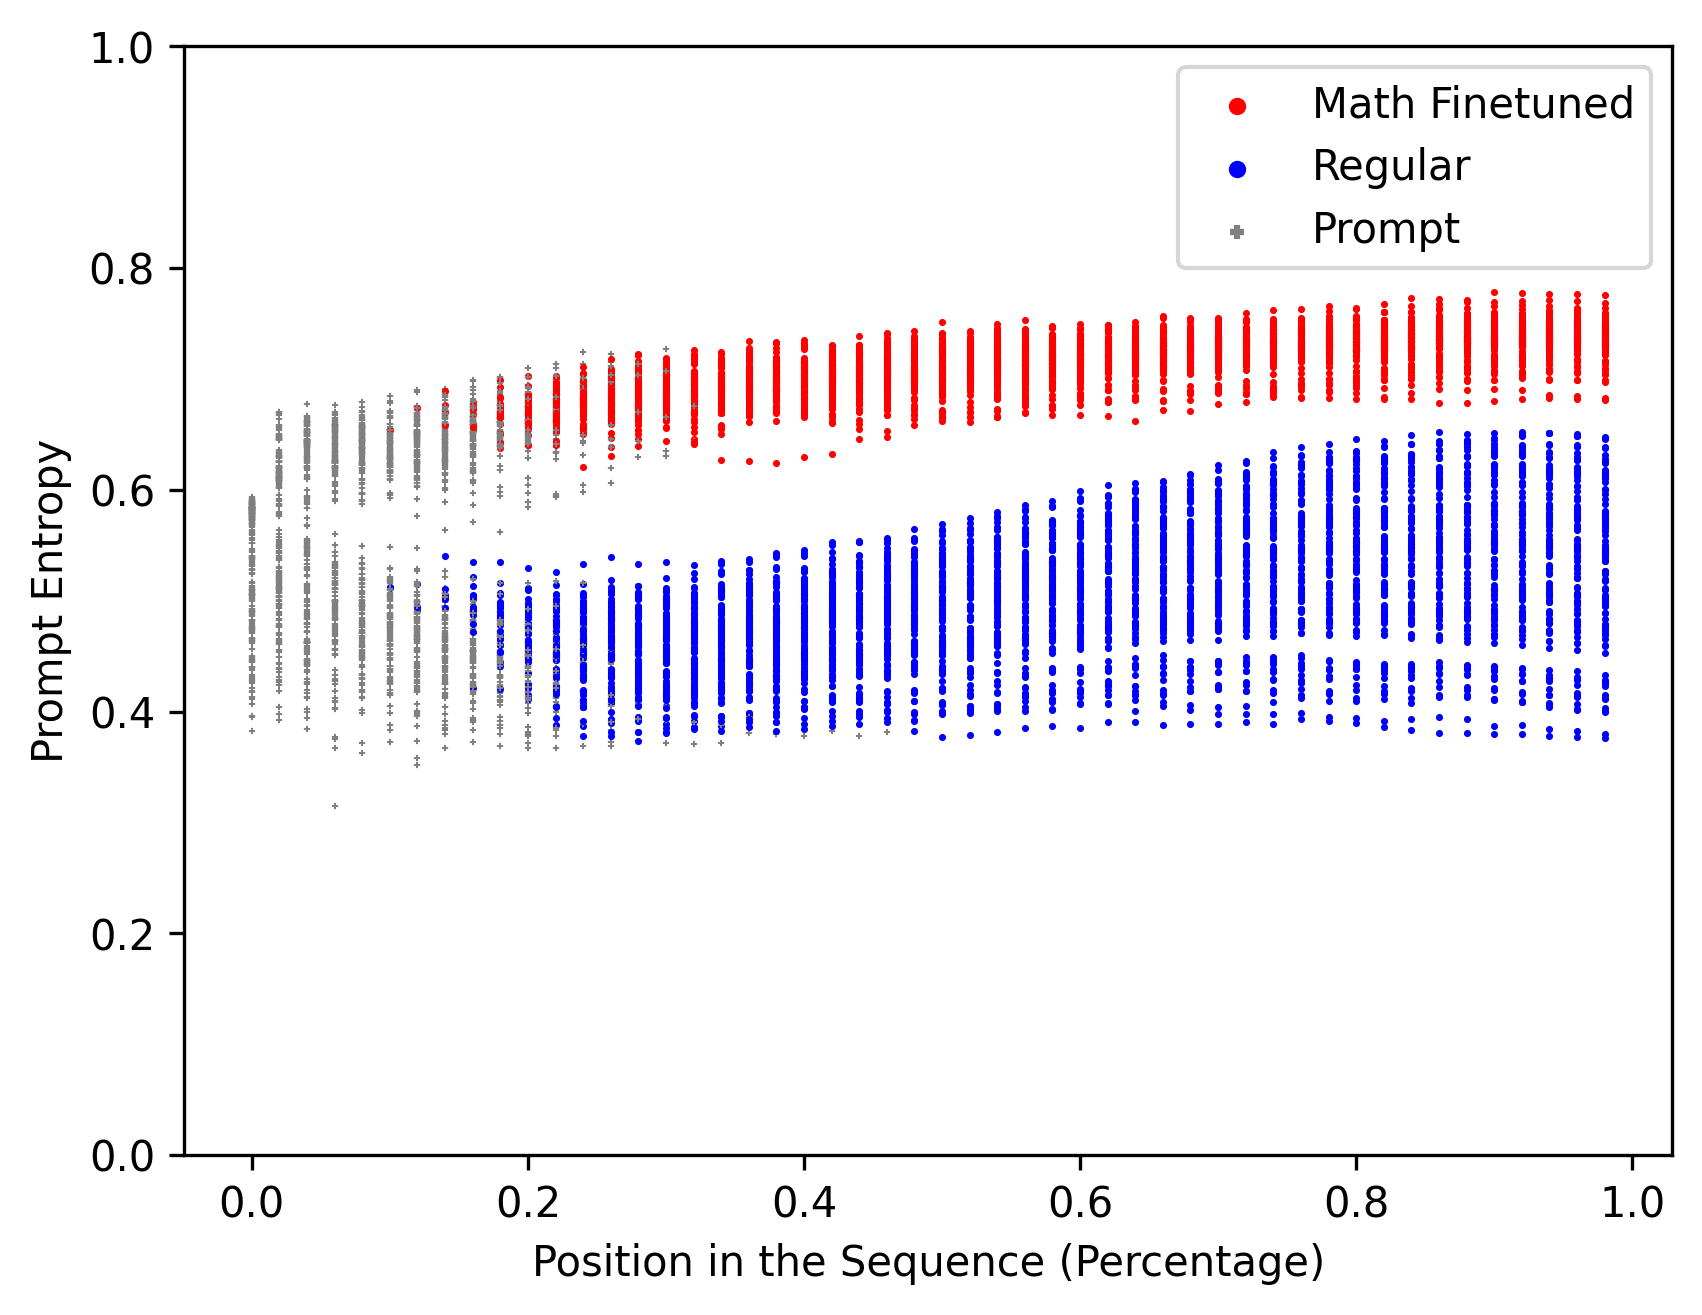

In [50]:
results_reg = pickle.load(open('results_reg.pkl', 'rb'))
results_prompt_reg = pickle.load(open('results_prompt_reg.pkl', 'rb'))

results_math = pickle.load(open('results_math.pkl', 'rb'))
results_prompt_math = pickle.load(open('results_prompt_math.pkl', 'rb'))

for i in range(len(results)):
    results = results_reg
    results_prompt = results_prompt_reg
    result = results[i]
    prompt_proportion = results_prompt[i]
    n_points = len(result)
    #the first n_points * prompt_proportion are the prompt, and the rest are the response color the prompt in red
    prompt_length = int(n_points * prompt_proportion)
    plt.scatter([x / n_points for x in range(prompt_length)], result[:prompt_length], c='gray', s=.5, marker='+')
    plt.scatter([x / n_points for x in range(prompt_length, n_points)], result[prompt_length:], c='b', s=.5)
    
    #plt.scatter([x for x in range(n_points)], result, c='b', s=1)
    
for i in range(len(results)):
    results = results_math
    results_prompt = results_prompt_math
    result = results[i]
    prompt_proportion = results_prompt[i]
    n_points = len(result)
    #the first n_points * prompt_proportion are the prompt, and the rest are the response color the prompt in red
    prompt_length = int(n_points * prompt_proportion)
    plt.scatter([x / n_points for x in range(prompt_length)], result[:prompt_length], c='gray', s=.5, marker='+')
    plt.scatter([x / n_points for x in range(prompt_length, n_points)], result[prompt_length:], c='r', s=.5)
    
    #plt.scatter([x for x in range(n_points)], result, c='b', s=1)

plt.xlabel('Position in the Sequence (Percentage)')

plt.ylim(0, 1)
plt.ylabel('Prompt Entropy')
#plt.title('Qwen 2.5 (Math) 1.5B')
plt.gcf().set_dpi(300)

plt.scatter([], [], c='r', s=10, label='Math Finetuned', marker='o')
plt.scatter([], [], c='b', s=10, label='Regular', marker='o')
plt.scatter([], [], c='gray', s=10, label='Prompt', marker='+')

plt.legend()
plt.show()

# Plotting

In [8]:
results['maxEntropy']
np.save('results_maxEntropy_qwen_25_math.npy', results['maxEntropy'])

KeyError: 'maxEntropy'

In [39]:
math = np.load('results_maxEntropy_qwen_25_math.npy', allow_pickle=True)
regular = np.load('results_maxEntropy_qwen_25.npy', allow_pickle=True)

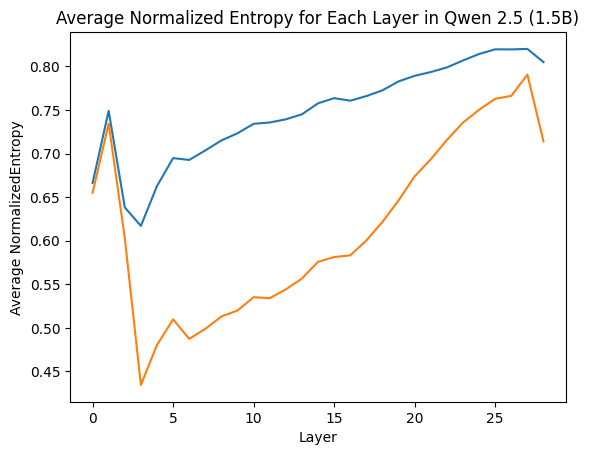

In [41]:
# plot average entropy for each layer
plt.plot(math.mean(axis=0), label='Qwen 2.5 (1.5B) Math')
plt.plot(regular.mean(axis=0), label='Qwen 2.5 (1.5B)')
plt.xlabel('Layer')
plt.ylabel('Average NormalizedEntropy')
plt.title('Average Normalized Entropy for Each Layer in Qwen 2.5 (1.5B)')
plt.legend()
plt.show()
